# Train YOLOv8 on TVD (Traffic Violation Detection) Dataset

**Classes:** No helmet, Triple riding, Using mobile

This notebook fine-tunes YOLOv8s on the TVD dataset for triple riding detection.
After training, download `best_tvd.pt` and place it in your project root alongside `best.pt`.

**Runtime:** Go to Runtime → Change runtime type → **T4 GPU**

## 1. Install Dependencies

In [1]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 152.9 MB/s eta 0:00:00


## 2. Download TVD Dataset from Roboflow

In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="X3CiWaVeiMfxPXIorqLh")
project = rf.workspace("traffic-violation-detection").project("tvd-kp9qw")
version = project.version(11)
dataset = version.download("yolov8")

print(f"\nDataset location: {dataset.location}")
print(f"data.yaml path:  {dataset.location}/data.yaml")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to TVD-11 in yolov8:: 100%|██████████| 3362/3362 [00:00<00:00, 4762.47it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Dataset location: /content/TVD-11
data.yaml path:  /content/TVD-11/data.yaml


## 3. Check Dataset Structure

In [3]:
import yaml

with open(f"{dataset.location}/data.yaml") as f:
    data_cfg = yaml.safe_load(f)

print("Classes:", data_cfg.get('names', data_cfg.get('nc')))
print("NC:", data_cfg.get('nc'))

import os
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset.location, split, 'images')
    if os.path.exists(img_dir):
        count = len(os.listdir(img_dir))
        print(f"{split}: {count} images")

Classes: ['No helmet', 'Triple riding', 'Using mobile', 'Wheeling']
NC: 4
train: 1467 images
valid: 136 images
test: 72 images


## 4. Train YOLOv8s on TVD

In [4]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")  # start from pretrained YOLOv8s

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,     # early stop
    plots=True,      # P/R curves, confusion matrix
    name="tvd_train",
)

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/TVD-11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tvd_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, 

## 5. Validate & Print Metrics

In [5]:
metrics = model.val()

print("\n" + "="*50)
print("TVD VALIDATION METRICS")
print("="*50)
print(f"mAP@0.5      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"Precision    : {metrics.box.mp:.4f}")
print(f"Recall       : {metrics.box.mr:.4f}")
print(f"\nBest weights : runs/detect/tvd_train/weights/best.pt")

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1812.5±770.9 MB/s, size: 52.8 KB)
val: Scanning /content/TVD-11/valid/labels.cache... 136 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 136/136 47.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.5it/s 6.1s
                   all        136        147      0.746      0.687      0.737      0.493
             No helmet        132        141      0.976      0.582      0.894      0.444
         Triple riding          2          2      0.902        0.5      0.495      0.396
          Using mobile          3          3      0.179      0.667      0.566      0.239
              Wheeling          1          1      0.928          1      0.995      0.895
Speed: 8.9ms preprocess, 10.2ms inference, 0.0ms l

## 6. Test on a Sample Image


image 1/1 /content/TVD-11/test/images/train-no-helmet-231-_jpg.rf.ece8f281d7b4111cf54fedd73e8ef277.jpg: 640x640 1 No helmet, 1 Using mobile, 16.2ms
Speed: 2.1ms preprocess, 16.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


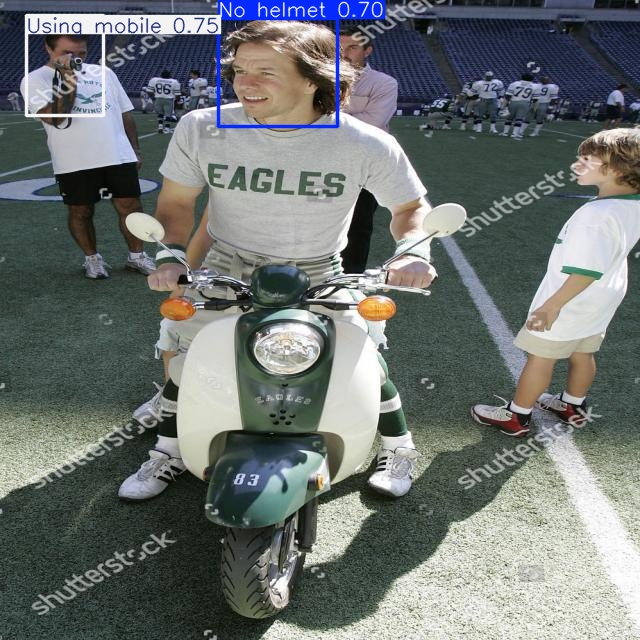


Model classes: {0: 'No helmet', 1: 'Triple riding', 2: 'Using mobile', 3: 'Wheeling'}


In [6]:
import glob
from IPython.display import display, Image as IPImage

# Load best weights
best_model = YOLO("runs/detect/tvd_train/weights/best.pt")

# Pick first test image
test_imgs = glob.glob(f"{dataset.location}/test/images/*")
if not test_imgs:
    test_imgs = glob.glob(f"{dataset.location}/valid/images/*")

if test_imgs:
    result = best_model(test_imgs[0], conf=0.25)[0]
    result.save(filename="tvd_test_result.jpg")
    display(IPImage(filename="tvd_test_result.jpg", width=640))
    print(f"\nModel classes: {best_model.names}")
else:
    print("No test images found.")

## 7. Download `best_tvd.pt`

Run this cell, then click the download link. Place the file as `best_tvd.pt` in your project root.

In [7]:
import shutil

src = "runs/detect/tvd_train/weights/best.pt"
dst = "best_tvd.pt"
shutil.copy(src, dst)
print(f"Copied {src} → {dst}")

# Google Colab file download
try:
    from google.colab import files
    files.download(dst)
except ImportError:
    print(f"Not on Colab — manually copy {dst} to your project.")

Copied runs/detect/tvd_train/weights/best.pt → best_tvd.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>